## **Milestone 3: Model Implementation** 
#### **Clustering and Classification Models** 


**By: Shugavaneshwar Rajan and Max White**

For this particular milestone, our group decided it would be best to use a collection of different models in order to draw out deeper insights from our data. The nature of our issue, Air Quality, has massive potential to benefit from machine learning models as they can help predict and identify areas most affected and most at risk of air pollutants. For this milestone, we decided to apply 4 separate models to our data and this notebook focuses on the clustering and classification models: KMeans and Random Forest

In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Air_Quality_Measures_on_the_National_Environmental_Health_Tracking_Network.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218635 entries, 0 to 218634
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MeasureId            218635 non-null  int64  
 1   MeasureName          218635 non-null  object 
 2   MeasureType          218635 non-null  object 
 3   StratificationLevel  218635 non-null  object 
 4   StateFips            218635 non-null  int64  
 5   StateName            218635 non-null  object 
 6   CountyFips           218635 non-null  int64  
 7   CountyName           218635 non-null  object 
 8   ReportYear           218635 non-null  int64  
 9   Value                218635 non-null  float64
 10  Unit                 218635 non-null  object 
 11  UnitName             218635 non-null  object 
 12  DataOrigin           218635 non-null  object 
 13  MonitorOnly          218635 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 23.4+ MB


,MeasureId,StateFips,CountyFips,ReportYear,Value,MonitorOnly
count,218635.000000,218635.000000,218635.000000,218635.000000,2.186350e+05,218635.000000
mean,248.436979,30.228980,30328.039536,2005.997777,6.499649e+05,0.383950
std,86.333124,15.139346,15157.173159,3.432221,1.160826e+07,0.486347
min,83.000000,1.000000,1001.000000,1999.000000,0.000000e+00,0.000000
25%,292.000000,18.000000,18146.000000,2003.000000,0.000000e+00,0.000000
50%,293.000000,29.000000,29189.000000,2006.000000,2.000000e+00,0.000000
75%,295.000000,45.000000,45021.000000,2009.000000,1.394105e+01,1.000000
max,296.000000,56.000000,56045.000000,2013.000000,1.084153e+09,1.000000


In [3]:
# There are a collection of measures to look at. We are going to extract only the ones of focus for this model implementation
print(df['MeasureName'].unique())

# This is to make for extracting the measures of interest easier
measure_pm25_avg = "Annual average ambient concentrations of PM2.5 in micrograms per cubic meter (based on seasonal averages and daily measurement)"
measure_pm25_avg_modeled = "Annual average ambient concentrations of PM 2.5 in micrograms per cubic meter, based on seasonal averages and daily measurement (monitor and modeled data)"
measure_pm25_pct_days = "Percent of days with PM2.5 levels over the National Ambient Air Quality Standard (NAAQS)"
measure_pm25_pct_days_modeled = "Percent of days with PM2.5 levels over the National Ambient Air Quality Standard (monitor and modeled data)"
measure_pm25_person_days = "Person-days with PM2.5 over the National Ambient Air Quality Standard"
measure_pm25_person_days_modeled = "Number of person-days with PM2.5 over the National Ambient Air Quality Standard (monitor and modeled data)"
measure_ozone_days = "Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard"
measure_ozone_days_modeled = "Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard (monitor and modeled data)"
measure_ozone_person_days = "Number of person-days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard"
measure_ozone_person_days_modeled = "Number of person-days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard (monitor and modeled data)"

# Collecting measures of interest
measures_of_interest = [
    measure_pm25_avg,
    measure_pm25_pct_days,
    measure_ozone_days,
    measure_pm25_avg_modeled,
    measure_pm25_pct_days_modeled,
    measure_ozone_days_modeled
]

['Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard'
 'Percent of days with PM2.5 levels over the National Ambient Air Quality Standard (NAAQS)'
 'Person-days with PM2.5 over the National Ambient Air Quality Standard'
 'Number of person-days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard'
 'Annual average ambient concentrations of PM2.5 in micrograms per cubic meter (based on seasonal averages and daily measurement)'
 'Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard (monitor and modeled data)'
 'Number of person-days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard (monitor and modeled data)'
 'Percent of days with PM2.5 levels over the National Ambient Air Quality Standard (monitor and modeled data)'
 'Number of person-days with PM2.5 over the National Ambient Air Quality 

In [4]:
#filter for relevant measures
df2 = df[df["MeasureName"].isin(measures_of_interest)]

# Pivot data so each county (or location) is a row, and each measure-year is a column
df_pivot = df2.pivot_table(
    index=["CountyFips", "ReportYear"], 
    columns="MeasureName",
    values="Value"
).reset_index()
df_pivot.head()

# We;re going to rename the features for readability
rename_map = {
    measure_pm25_avg: "PM25_avg",
    measure_pm25_avg_modeled: "PM25_avg_model",
    measure_pm25_pct_days: "PM25_pct_days",
    measure_pm25_pct_days_modeled: "PM25_pct_days_model",
    measure_ozone_days: "Ozone_days",
    measure_ozone_days_modeled: "Ozone_days_model",
}

df_pivot = df_pivot.rename(columns=rename_map)

In [5]:
#Handling missing values
df_pivot = df_pivot.ffill().bfill()

# Creating new features for trend
df_pivot["PM25_trend"] = df_pivot.groupby("CountyFips")["PM25_avg"].diff()
features = ["PM25_avg", "PM25_pct_days", "Ozone_days", "PM25_trend"]

X = df_pivot[features].dropna()

In [6]:
# Standardize and scale our features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

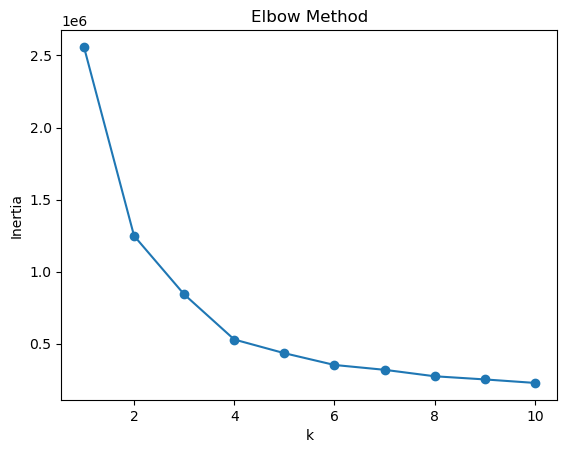

'\nOur findings suggest that we should be using 4 groups or k=4\n'

In [7]:
#Clustering: KMeans
# We first are using the elbow method to determine how many clusters we should use
inertias = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(km.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

"""
Our findings suggest that we should be using 4 groups or k=4
"""

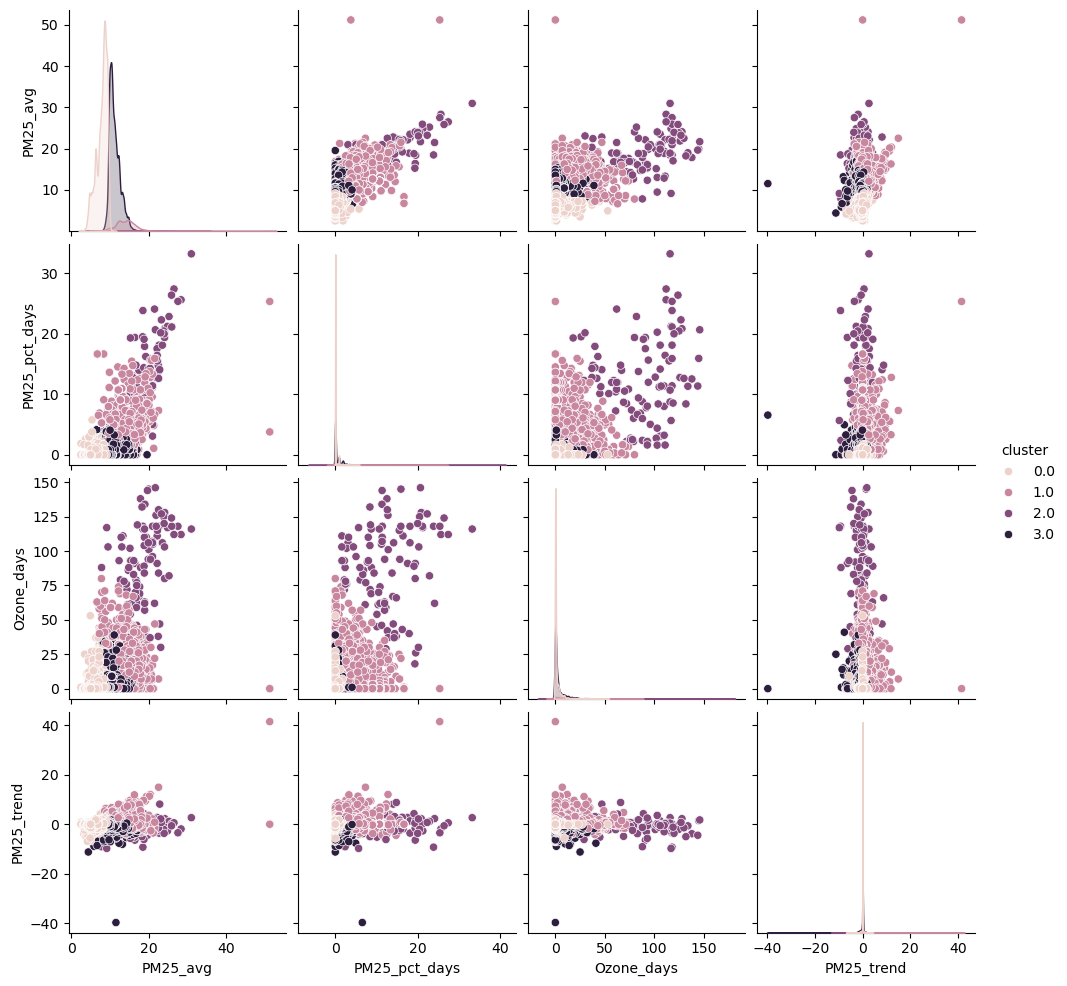

In [8]:
# KMeans Continued
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_pivot.loc[X.index, "cluster"] = clusters
sns.pairplot(df_pivot.dropna(subset=features + ["cluster"]),
             hue="cluster", vars=features)
plt.show()

In [9]:
# Classification: RandomForest

# Identifying high risk zones: areas in top 25% of ozone days
threshold = df_pivot["Ozone_days"].quantile(0.75)

df_pivot["high_ozone_risk"] = (df_pivot["Ozone_days"] > threshold).astype(int)

X_cls = df_pivot[features].dropna()
y = df_pivot.loc[X_cls.index, "high_ozone_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y, test_size=0.3, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7833
           1       1.00      1.00      1.00      2558

    accuracy                           1.00     10391
   macro avg       1.00      1.00      1.00     10391
weighted avg       1.00      1.00      1.00     10391



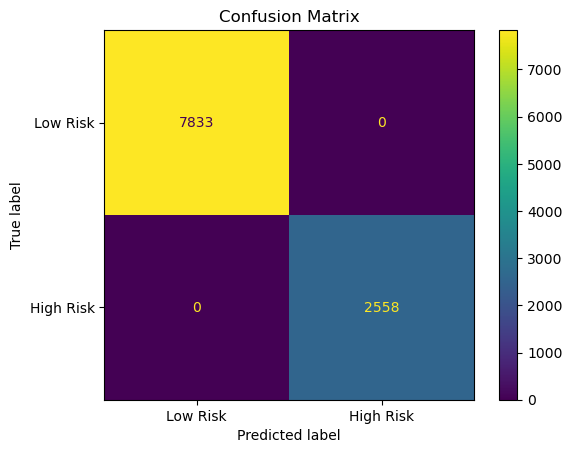

In [10]:
# Evaluation
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Low Risk", "High Risk"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

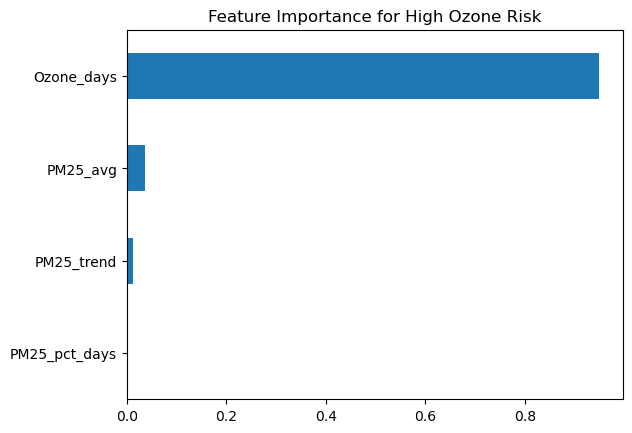

In [11]:
# Feature importance
importances = pd.Series(clf.feature_importances_, index=features)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance for High Ozone Risk")
plt.show()

In [12]:
# Saving Results
df_pivot.to_csv("county_air_quality_clusters.csv", index=False)
joblib.dump(clf, "ozone_risk_clf.pkl")

['ozone_risk_clf.pkl']

In [13]:
df.head()

,MeasureId,MeasureName,MeasureType,StratificationLevel,StateFips,StateName,CountyFips,CountyName,ReportYear,Value,Unit,UnitName,DataOrigin,MonitorOnly
0,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1027,Clay,1999,33.0,No Units,No Units,Monitor Only,1
1,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1051,Elmore,1999,5.0,No Units,No Units,Monitor Only,1
2,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1073,Jefferson,1999,39.0,No Units,No Units,Monitor Only,1
3,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1079,Lawrence,1999,28.0,No Units,No Units,Monitor Only,1
4,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1089,Madison,1999,31.0,No Units,No Units,Monitor Only,1


In [14]:
df_pivot.head()

MeasureName,CountyFips,ReportYear,PM25_avg_model,PM25_avg,Ozone_days,Ozone_days_model,PM25_pct_days,PM25_pct_days_model,PM25_trend,cluster,high_ozone_risk
0,1001,2001,13.186807,14.528161,34.0,3.0,2.352941,0.000000,NaN,NaN,1
1,1001,2002,12.490668,14.528161,34.0,6.0,2.352941,0.273973,0.0,1.0,1
2,1001,2003,12.869481,14.528161,34.0,2.0,2.352941,0.273973,0.0,1.0,1
3,1001,2004,13.111945,14.528161,34.0,0.0,2.352941,1.366120,0.0,1.0,1
4,1001,2005,13.543276,14.528161,34.0,0.0,2.352941,1.369863,0.0,1.0,1
